# NBA Salary vs Performance Analysis (2025–26 Season)

## Objective
The goal of this project is to examine the relationship between NBA player salaries and performance metrics. Specifically, we aim to determine whether statistics such as points, assists, rebounds, and minutes played can explain variation in player salaries.

This analysis combines salary data with player performance statistics and applies statistical methods including regression analysis, hypothesis testing, and grouping to uncover patterns in compensation.

## Data Overview

The dataset used in this analysis is the result of merging two sources:
- Player salary data for the 2025–26 NBA season
- Player performance statistics (PTS, AST, TRB, MP)

The merge was performed using player identifiers, ensuring that each observation corresponds to a unique player-season.

Before analysis, the dataset is inspected for missing values, incorrect data types, and formatting issues.

In [ ]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
import scipy.stats as stats
import statsmodels.formula.api as smf

# Load dataset
df = pd.read_csv('merged_nba_2025_26.csv')

# Preview
print(df.head())

# Check missing values
print(df.isnull().sum())

# Drop missing if necessary
df = df.dropna()

               Player   Season   PTS  AST   TRB    MP Salary_2025-26
0         Ivica Zubac  2025-26  14.1  2.2  10.6  30.1   $18,893,980 
1          Trae Young  2025-26  17.9  8.0   2.0  25.6   $46,394,100 
2  Guerschon Yabusele  2025-26   5.6  0.9   3.5  15.0    $5,500,000 
3          Danny Wolf  2025-26   8.9  2.2   4.9  20.8    $2,801,280 
4       James Wiseman  2025-26   3.3  0.8   2.0  14.5    $1,131,970 
Player            0
Season            0
PTS               0
AST               0
TRB               0
MP                0
Salary_2025-26    0
dtype: int64


The code successfully imports all necessary packages and loads the dataset.

View the dataframe's information to determine that all columns are in the correct datatype and contain no missing values.

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472 entries, 0 to 471
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Player          472 non-null    object 
 1   Season          472 non-null    object 
 2   PTS             472 non-null    float64
 3   AST             472 non-null    float64
 4   TRB             472 non-null    float64
 5   MP              472 non-null    float64
 6   Salary_2025-26  472 non-null    object 
dtypes: float64(4), object(3)
memory usage: 25.9+ KB


From this we discovered that the Salary_2025-26 column has the Dtype object, however we require it to be a float as it represents units of currency that we need to use in computations.

To resolve this, we write code that remove punctuation(commas, currency symbol) and convert the observations in the column to numeric using pandas.

In [67]:
# Clean + convert Salary column
df['Salary_2025-26'] = pd.to_numeric(
    df['Salary_2025-26'].replace('[\$,]', '', regex=True),
    errors='coerce'
)

# Check results
print("Data type:", df['Salary_2025-26'].dtype)
print("Missing values after conversion:", df['Salary_2025-26'].isnull().sum())

# Rename column for easier use in analysis
df.rename(columns={'Salary_2025-26': 'Salary'}, inplace=True)

# Preview
print(df[['Salary']].head())

Data type: int64
Missing values after conversion: 0
     Salary
0  18893980
1  46394100
2   5500000
3   2801280
4   1131970


<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Maseg\AppData\Local\Temp\ipykernel_522228\2634802190.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['Salary_2025-26'].replace('[\$,]', '', regex=True),


## Data Cleaning

The salary variable was originally stored as an object due to formatting (e.g., dollar signs and commas). It was cleaned and converted into a numeric format to allow for statistical analysis.

Missing values were handled by removing incomplete observations to ensure consistency across variables used in the analysis.

## Exploratory Data Analysis

We begin by examining summary statistics and visualizations to understand the distribution of key variables.

This includes:
- Distribution of salaries
- Relationships between salary and performance metrics
- Correlation analysis

These steps help identify patterns and guide the selection of appropriate statistical models.

              PTS         AST         TRB          MP        Salary
count  472.000000  472.000000  472.000000  472.000000  4.720000e+02
mean    10.205508    2.373729    3.916949   21.358051  1.144290e+07
std      6.457568    1.835261    2.331791    8.231745  1.334831e+07
min      0.000000    0.000000    0.000000    3.000000  2.194600e+04
25%      5.350000    1.000000    2.300000   15.175000  2.296274e+06
50%      8.700000    1.900000    3.400000   21.800000  5.700060e+06
75%     13.800000    3.225000    5.125000   28.325000  1.413587e+07
max     33.500000   10.700000   12.900000   38.000000  5.960682e+07


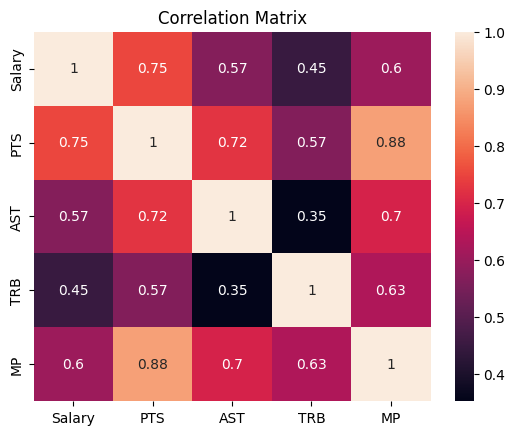

In [68]:
# Summary statistics
print(df.describe())

# Correlation matrix


sns.heatmap(df[['Salary','PTS','AST','TRB','MP']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

The resulting heatmap of correlations shows the strength of relations between variables.

## Hypothesis Testing

To evaluate the relationship between performance and salary, we conduct hypothesis testing using regression models.

Example hypothesis:
- Null hypothesis (H₀): Player performance (e.g., points) has no effect on salary
- Alternative hypothesis (H₁): Player performance significantly affects salary

Statistical significance is assessed using p-values.

In [69]:
X = df['PTS']
Y = df['Salary']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.561
Method:                 Least Squares   F-statistic:                     603.2
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.62e-86
Time:                        00:46:49   Log-Likelihood:                -8218.4
No. Observations:                 472   AIC:                         1.644e+04
Df Residuals:                     470   BIC:                         1.645e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.373e+06   7.62e+05     -5.740      0.0

## Multiple Linear Regression

A multiple linear regression model is used to estimate the relationship between salary and multiple performance metrics:

Salary = β₀ + β₁PTS + β₂AST + β₃TRB + β₄MP + ε

This model allows us to isolate the effect of each variable while controlling for others.

Key outputs include:
- Coefficient estimates
- R-squared (model fit)
- p-values (statistical significance)

In [70]:
X = df[['PTS','AST','TRB','MP']]
Y = df['Salary']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     163.3
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.57e-87
Time:                        00:46:49   Log-Likelihood:                -8206.8
No. Observations:                 472   AIC:                         1.642e+04
Df Residuals:                     467   BIC:                         1.644e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -7.21e+05   1.25e+06     -0.577      0.5

## Analysis of Variance (ANOVA)

ANOVA is used to test the overall significance of the regression model.

The null hypothesis is that all coefficients (except the intercept) are equal to zero. A statistically significant result indicates that at least one predictor variable contributes to explaining variation in salary.

In [71]:
anova_model = smf.ols(
    formula='Salary ~ PTS + AST + TRB + MP',
    data=df
).fit()

# ANOVA table
anova_results = anova_lm(anova_model, typ=2)

print(anova_results)

                sum_sq     df           F        PR(>F)
PTS       1.350586e+16    1.0  180.281787  5.463098e-35
AST       4.016893e+14    1.0    5.361913  2.101359e-02
TRB       5.670302e+14    1.0    7.568951  6.169061e-03
MP        1.562885e+15    1.0   20.862026  6.323440e-06
Residual  3.498545e+16  467.0         NaN           NaN


## Variance Inference

A confidence interval for the population variance of salaries is constructed using the chi-square distribution.

This provides insight into the level of dispersion in player salaries and helps quantify the variability within the dataset.

In [72]:

n = len(df['Salary'])
var_sample = np.var(df['Salary'], ddof=1)

alpha = 0.05

chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)
chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)

lower = (n-1)*var_sample / chi2_upper
upper = (n-1)*var_sample / chi2_lower

print("95% CI for variance:", (lower, upper))

95% CI for variance: (np.float64(157443452909988.72), np.float64(203317592839629.2))


In [73]:
sqrt_lower = np.sqrt(lower)
sqrt_upper = np.sqrt(upper)
print("95% CI for standard deviation:", (sqrt_lower, sqrt_upper))

95% CI for standard deviation: (np.float64(12547647.305769665), np.float64(14258947.81670896))


In [74]:
modelqr = smf.quantreg('Salary ~ PTS + AST + TRB + MP', df)
res = modelqr.fit(q=0.5)  # median
print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:                 Salary   Pseudo R-squared:               0.2884
Model:                       QuantReg   Bandwidth:                   4.301e+06
Method:                 Least Squares   Sparsity:                    1.534e+07
Date:                Mon, 27 Apr 2026   No. Observations:                  472
Time:                        00:46:49   Df Residuals:                      467
                                        Df Model:                            4
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.235e+06   1.11e+06      1.115      0.265   -9.41e+05    3.41e+06
PTS         1.941e+06    1.2e+05     16.113      0.000     1.7e+06    2.18e+06
AST         8.684e+05   2.89e+05      3.007      0.003    3.01e+05    1.44e+06
TRB         6.662e+05   1.99e+05      3.355      0.0

## Residual Analysis

Residuals represent the difference between actual and predicted salaries.

Analyzing residuals helps:
- Identify model fit issues
- Detect heteroskedasticity
- Highlight players who may be overpaid or underpaid relative to their performance

This provides insight into potential inefficiencies in salary allocation.

In [75]:
df['predicted_salary'] = res.predict(df)
df['residual'] = df['Salary'] - df['predicted_salary']
df['residual'] = df['Salary'] - df['predicted_salary']

To illustrate the relationship, some plots and figures between variables are constructed using matplotlib

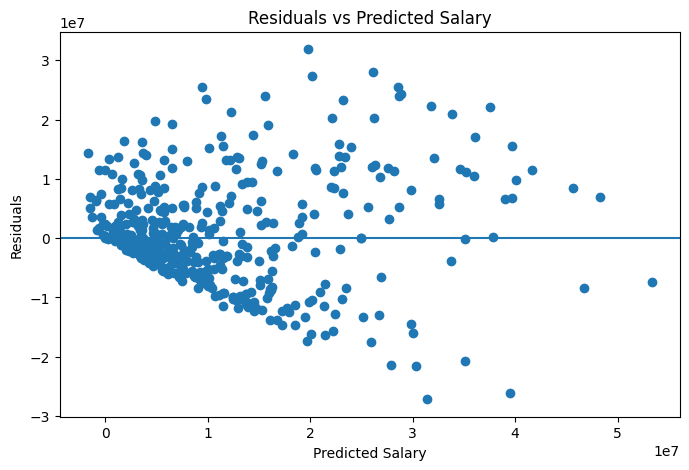

In [76]:
plt.figure(figsize=(8,5))
plt.scatter(df['predicted_salary'], df['residual'])
plt.axhline(0)
plt.title('Residuals vs Predicted Salary')
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals')
plt.show()

### Residuals vs Predicted Salary

The residual plot compares predicted salaries from the regression model to the actual deviations (residuals). Ideally, residuals should be randomly distributed around zero, indicating a well-specified model.

However, the plot exhibits a clear fan-shaped pattern, where the spread of residuals increases as predicted salary increases. This indicates the presence of heteroskedasticity, meaning that the variance of errors is not constant across observations.

From a modeling perspective, this suggests that the regression performs better for lower- and mid-salary players, but becomes less reliable for higher-paid players. It also implies that additional variables or alternative modeling approaches may be needed to better capture salary dynamics at the upper end of the distribution.

Additionally, large positive and negative residuals highlight players whose salaries are significantly over- or under-predicted by the model, providing insight into potential inefficiencies or omitted factors.

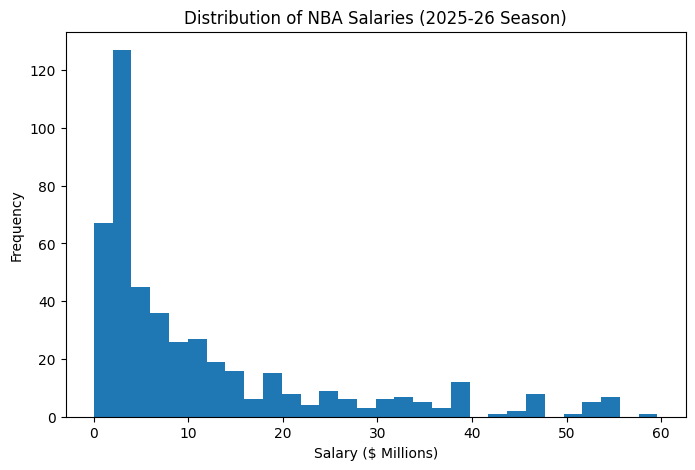

In [84]:
df['Salary_millions'] = df['Salary'] / 1_000_000

plt.figure(figsize=(8,5))
plt.hist(df['Salary_millions'], bins=30)
plt.title('Distribution of NBA Salaries (2025-26 Season)')
plt.xlabel('Salary ($ Millions)')
plt.ylabel('Frequency')
plt.show()

### Distribution of Salaries

The distribution of player salaries is highly right-skewed, with the majority of players earning relatively lower salaries and a small number of players earning significantly higher amounts. Most salaries are concentrated below $10 million, while a few extreme values extend far into the upper range.

This pattern reflects the structure of the NBA labor market, where superstar players command disproportionately large contracts compared to the average player. The presence of this skewness suggests that the data may violate normality assumptions, which has implications for statistical modeling.

As a result, transformations such as taking the logarithm of salary may be useful in stabilizing variance and improving model performance.

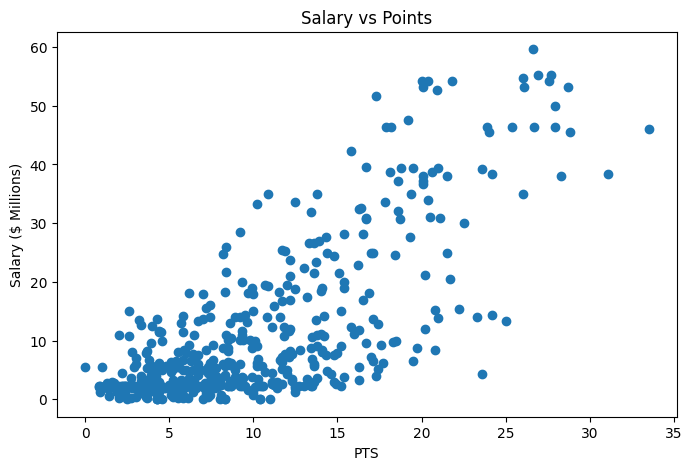

In [78]:
plt.figure(figsize=(8,5))
plt.scatter(df['PTS'], df['Salary_millions'])

plt.title('Salary vs Points')
plt.xlabel('PTS')
plt.ylabel('Salary ($ Millions)')
plt.show()

### Salary vs Points

The scatterplot of salary versus points per game shows a clear positive relationship, indicating that scoring is a key driver of player compensation. As points increase, salaries tend to rise, suggesting that teams place a high value on offensive production.

However, the spread of salaries widens at higher scoring levels, indicating greater variability among top performers. This suggests that while scoring is important, it is not the sole determinant of salary. Factors such as experience, reputation, contract timing, and team role may contribute to the observed variation.

Overall, this plot provides strong visual evidence that points per game is one of the most influential predictors of salary.

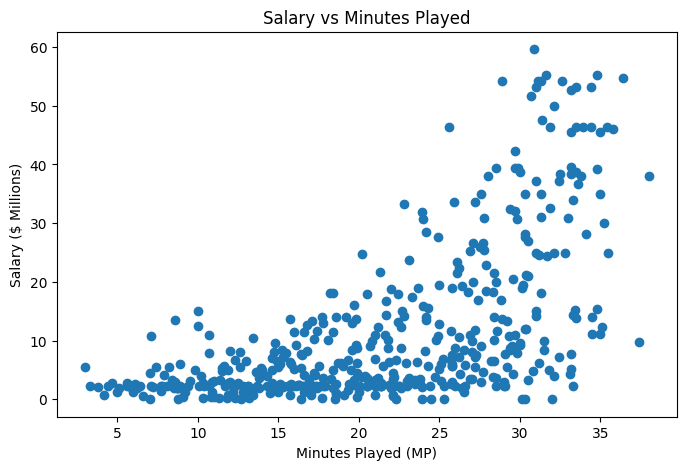

In [79]:
plt.figure(figsize=(8,5))
plt.scatter(df['MP'], df['Salary_millions'])
plt.title('Salary vs Minutes Played')
plt.xlabel('Minutes Played (MP)')
plt.ylabel('Salary ($ Millions)')
plt.show()

### Salary vs Minutes Played

The relationship between salary and minutes played also appears to be positive, indicating that players who receive more playing time tend to earn higher salaries. This reflects the importance of player utilization and role within a team.

However, compared to points, the relationship is less tightly clustered, with greater dispersion in salaries for a given level of minutes played. This suggests that playing time alone is not a precise predictor of salary.

In particular, some players with high minutes played earn relatively modest salaries, which may reflect lower efficiency or role-specific responsibilities. Conversely, some high-salary players do not have proportionally high minutes, potentially due to factors such as injuries, load management, or superstar status.

This indicates that minutes played contributes to salary determination, but its effect is more indirect and intertwined with other performance metrics.

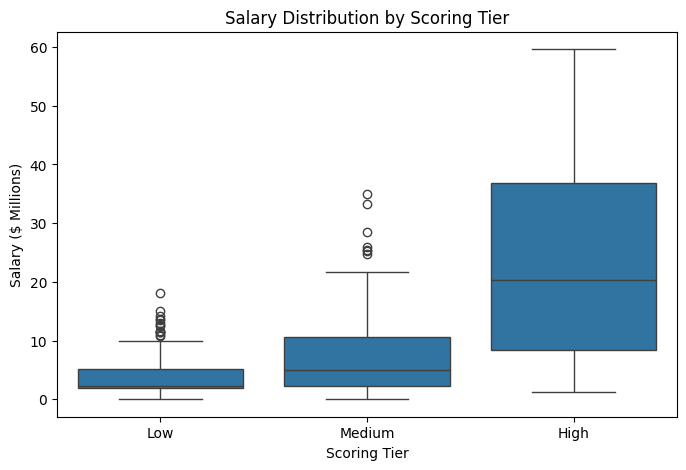

In [80]:
# Create performance tiers based on PTS
df['PTS_group'] = pd.qcut(df['PTS'], q=3, labels=['Low','Medium','High'])

plt.figure(figsize=(8,5))
sns.boxplot(x='PTS_group', y='Salary_millions', data=df)
plt.title('Salary Distribution by Scoring Tier')
plt.xlabel('Scoring Tier')
plt.ylabel('Salary ($ Millions)')
plt.show()

The distribution of salaries shows that most players earn below $10 million.
However, when grouped by scoring tiers, players in the high-scoring tier
tend to have higher average salaries and higher maximum salaries compared
to medium and low tiers. This suggests a strong relationship between scoring
performance and compensation.

That said, there are notable outliers in the low and medium scoring tiers,
where some players earn relatively high salaries. These deviations are likely
driven by factors not captured in the model, such as years of experience
(Years Pro), contract structure, or specific team roles (e.g., defensive
specialists or veteran leadership).

Similarly, some players in the high-scoring tier may earn lower salaries,
which could reflect early-career contracts or undervaluation relative to
performance.